# Linear Ridge Models

This notebook documents the Ridge regression models used as the first supervised-learning benchmarks.

The notebook covers:

1. motivation for the linear benchmark  
2. Ridge model results with the `daily` feature set  
3. Ridge model results with the `daily_ohlcv` feature set  
4. comparison of prediction and portfolio performance  
5. interpretation of the linear benchmark family  

The purpose of this notebook is to establish simple supervised-learning reference models before moving to more flexible nonlinear methods.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)
print("src exists:", (PROJECT_ROOT / "src").exists())

Project root: c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml
src exists: True


In [2]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.utils.plotting import (
    STYLE,
    get_model_color,
    plot_equity_curve,
    plot_drawdown,
    plot_multi_series,
    plot_metric_bar,
    plot_grouped_metric_bars,
)

In [3]:
NOTEBOOK_NAME = "notebook04"

REPORTS_DIR = PROJECT_ROOT / "reports"
TABLES_DIR = REPORTS_DIR / "tables" / NOTEBOOK_NAME
FIGURES_DIR = REPORTS_DIR / "figures" / NOTEBOOK_NAME
EXPORTS_DIR = REPORTS_DIR / "exports"

TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
EXPORTS_DIR.mkdir(parents=True, exist_ok=True)

print("Tables dir :", TABLES_DIR)
print("Figures dir:", FIGURES_DIR)

Tables dir : c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\reports\tables\notebook04
Figures dir: c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\reports\figures\notebook04


In [4]:
def save_table(df: pd.DataFrame, filename: str, index: bool = False) -> None:
    path = TABLES_DIR / filename
    df.to_csv(path, index=index)
    print(f"Saved table -> {path}")


def fig_path(filename: str) -> str:
    return str(FIGURES_DIR / filename)

## 1. Why use a linear model?

Ridge regression provides a useful benchmark because:

- it is simple and interpretable  
- it imposes regularization on coefficient estimates  
- it shows what can be achieved with a linear mapping from features to returns  

Even if more flexible models perform better later, the Ridge model remains important as a transparent reference point.

In [5]:
ridge_dirs = {
    "Ridge daily": PROJECT_ROOT / "experiments" / "results" / "exp02_linear_ridge_daily",
    "Ridge daily_ohlcv": PROJECT_ROOT / "experiments" / "results" / "exp02_linear_ridge_daily_ohlcv",
}

ridge_dirs

{'Ridge daily': WindowsPath('c:/Users/amila/OneDrive/UH/DSP/Git/stability-aware-stock-momentum-ml/experiments/results/exp02_linear_ridge_daily'),
 'Ridge daily_ohlcv': WindowsPath('c:/Users/amila/OneDrive/UH/DSP/Git/stability-aware-stock-momentum-ml/experiments/results/exp02_linear_ridge_daily_ohlcv')}

In [6]:
for name, ridge_dir in ridge_dirs.items():
    print(f"\n{name}")
    print("dir:", ridge_dir)
    for fn in [
        "prediction_metrics.json",
        "metrics_train.json",
        "metrics_test_2025.json",
        "metrics_train_with_costs.json",
        "metrics_test_2025_with_costs.json",
        "equity_train.csv",
        "equity_test_2025.csv",
    ]:
        print(f"{fn}: {(ridge_dir / fn).exists()}")


Ridge daily
dir: c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\experiments\results\exp02_linear_ridge_daily
prediction_metrics.json: True
metrics_train.json: True
metrics_test_2025.json: True
metrics_train_with_costs.json: True
metrics_test_2025_with_costs.json: True
equity_train.csv: True
equity_test_2025.csv: True

Ridge daily_ohlcv
dir: c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\experiments\results\exp02_linear_ridge_daily_ohlcv
prediction_metrics.json: True
metrics_train.json: True
metrics_test_2025.json: True
metrics_train_with_costs.json: True
metrics_test_2025_with_costs.json: True
equity_train.csv: True
equity_test_2025.csv: True


In [7]:
def load_ridge_experiment(exp_dir: Path) -> dict:
    with open(exp_dir / "prediction_metrics.json", "r") as f:
        prediction_metrics = json.load(f)

    with open(exp_dir / "metrics_train.json", "r") as f:
        metrics_train = json.load(f)

    with open(exp_dir / "metrics_test_2025.json", "r") as f:
        metrics_test = json.load(f)

    with open(exp_dir / "metrics_train_with_costs.json", "r") as f:
        metrics_train_costs = json.load(f)

    with open(exp_dir / "metrics_test_2025_with_costs.json", "r") as f:
        metrics_test_costs = json.load(f)

    equity_train = pd.read_csv(exp_dir / "equity_train.csv", index_col=0).squeeze("columns")
    equity_test = pd.read_csv(exp_dir / "equity_test_2025.csv", index_col=0).squeeze("columns")

    equity_train.index = pd.to_datetime(equity_train.index)
    equity_test.index = pd.to_datetime(equity_test.index)

    return {
        "prediction_metrics": prediction_metrics,
        "metrics_train": metrics_train,
        "metrics_test": metrics_test,
        "metrics_train_costs": metrics_train_costs,
        "metrics_test_costs": metrics_test_costs,
        "equity_train": equity_train,
        "equity_test": equity_test,
    }

In [8]:
ridge_results = {name: load_ridge_experiment(path) for name, path in ridge_dirs.items()}
ridge_results.keys()

dict_keys(['Ridge daily', 'Ridge daily_ohlcv'])

In [9]:
ridge_setup = pd.DataFrame(
    {
        "model_variant": ["Ridge daily", "Ridge daily_ohlcv"],
        "feature_source": ["daily", "daily_ohlcv"],
        "regularization": ["L2", "L2"],
    }
)
ridge_setup

,model_variant,feature_source,regularization
0,Ridge daily,daily,L2
1,Ridge daily_ohlcv,daily_ohlcv,L2


In [10]:
save_table(ridge_setup, "ridge_setup_summary.csv", index=False)

Saved table -> c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\reports\tables\notebook04\ridge_setup_summary.csv


## 2. Prediction metrics

The Ridge models are first evaluated as return prediction models.

These metrics measure:

- numerical prediction error  
- sign correctness  
- ranking quality across stocks within each month

In [11]:
prediction_rows = []

for model_name, res in ridge_results.items():
    pm = res["prediction_metrics"]

    prediction_rows.append(
        {
            "model": model_name,
            "split": "train_2015_2024",
            "MAE": pm["train"]["regression"]["MAE"],
            "RMSE": pm["train"]["regression"]["RMSE"],
            "R2": pm["train"]["regression"]["R2"],
            "Directional_Accuracy": pm["train"]["regression"]["Directional_Accuracy"],
            "SpearmanRankCorr_mean": pm["train"]["ranking"]["SpearmanRankCorr_mean"],
            "TopKHitRate_mean": pm["train"]["ranking"]["TopKHitRate_mean"],
            "Months_evaluated": pm["train"]["ranking"]["Months_evaluated"],
        }
    )

    prediction_rows.append(
        {
            "model": model_name,
            "split": "test_2025",
            "MAE": pm["test_2025"]["regression"]["MAE"],
            "RMSE": pm["test_2025"]["regression"]["RMSE"],
            "R2": pm["test_2025"]["regression"]["R2"],
            "Directional_Accuracy": pm["test_2025"]["regression"]["Directional_Accuracy"],
            "SpearmanRankCorr_mean": pm["test_2025"]["ranking"]["SpearmanRankCorr_mean"],
            "TopKHitRate_mean": pm["test_2025"]["ranking"]["TopKHitRate_mean"],
            "Months_evaluated": pm["test_2025"]["ranking"]["Months_evaluated"],
        }
    )

ridge_prediction_comparison = pd.DataFrame(prediction_rows)
ridge_prediction_comparison

,model,split,MAE,RMSE,R2,Directional_Accuracy,SpearmanRankCorr_mean,TopKHitRate_mean,Months_evaluated
0,Ridge daily,train_2015_2024,0.059068,0.080983,0.017457,0.530524,0.019285,0.277330,109
1,Ridge daily,test_2025,0.054522,0.073360,0.017624,0.554688,0.042863,0.301435,11
2,Ridge daily_ohlcv,train_2015_2024,0.058916,0.080614,0.023433,0.536148,0.027545,0.280565,109
3,Ridge daily_ohlcv,test_2025,0.054716,0.073867,0.004009,0.561523,0.048692,0.272727,11


In [12]:
save_table(ridge_prediction_comparison, "ridge_prediction_metrics_comparison.csv", index=False)

Saved table -> c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\reports\tables\notebook04\ridge_prediction_metrics_comparison.csv


## 3. Strategy metrics

The Ridge models are also evaluated as portfolio-ranking models.

This stage measures whether the predicted returns are useful for selecting stocks and forming a portfolio.

In [13]:
strategy_rows = []

for model_name, res in ridge_results.items():
    mt = res["metrics_train"]
    ms = res["metrics_test"]

    strategy_rows.append(
        {
            "model": model_name,
            "split": "train_2015_2024",
            **mt,
        }
    )
    strategy_rows.append(
        {
            "model": model_name,
            "split": "test_2025",
            **ms,
        }
    )

ridge_strategy_comparison = pd.DataFrame(strategy_rows)
ridge_strategy_comparison

,model,split,cumulative_return,annualized_return,annualized_volatility,max_drawdown,sharpe_ratio,avg_turnover,median_turnover,max_turnover
0,Ridge daily,train_2015_2024,2.059585,0.118320,0.211222,-0.360617,0.637635,0.396330,0.400000,0.700000
1,Ridge daily,test_2025,0.217607,0.217607,0.155976,-0.061110,1.341890,0.425837,0.473684,0.578947
2,Ridge daily_ohlcv,train_2015_2024,2.502620,0.133546,0.214547,-0.384081,0.694521,0.423853,0.400000,0.700000
3,Ridge daily_ohlcv,test_2025,0.160716,0.160716,0.161868,-0.072571,0.999271,0.454545,0.473684,0.578947


In [14]:
save_table(ridge_strategy_comparison, "ridge_strategy_metrics_comparison.csv", index=False)

Saved table -> c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\reports\tables\notebook04\ridge_strategy_metrics_comparison.csv


In [15]:
cost_rows = []

for model_name, res in ridge_results.items():
    for split_name, cost_dict in [
        ("train_2015_2024", res["metrics_train_costs"]),
        ("test_2025", res["metrics_test_costs"]),
    ]:
        for cost_name, metrics in cost_dict.items():
            row = {
                "model": model_name,
                "split": split_name,
                "cost_scenario": cost_name,
            }
            row.update(metrics)
            cost_rows.append(row)

ridge_cost_comparison = pd.DataFrame(cost_rows)
ridge_cost_comparison

,model,split,cost_scenario,cumulative_return,annualized_return,annualized_volatility,max_drawdown,sharpe_ratio,avg_turnover,median_turnover,max_turnover
0,Ridge daily,train_2015_2024,cost_0bps,2.059585,0.118320,0.211222,-0.360617,0.637635,0.396330,0.400000,0.700000
1,Ridge daily,train_2015_2024,cost_10bps,1.930954,0.113527,0.211228,-0.361414,0.617166,0.396330,0.400000,0.700000
2,Ridge daily,train_2015_2024,cost_20bps,1.807679,0.108753,0.211235,-0.362211,0.596695,0.396330,0.400000,0.700000
3,Ridge daily,test_2025,cost_0bps,0.217607,0.217607,0.155976,-0.061110,1.341890,0.425837,0.473684,0.578947
4,Ridge daily,test_2025,cost_10bps,0.212008,0.212008,0.155939,-0.062340,1.312170,0.425837,0.473684,0.578947
5,Ridge daily,test_2025,cost_20bps,0.206432,0.206432,0.155904,-0.063806,1.282412,0.425837,0.473684,0.578947
6,Ridge daily_ohlcv,train_2015_2024,cost_0bps,2.502620,0.133546,0.214547,-0.384081,0.694521,0.423853,0.400000,0.700000
7,Ridge daily_ohlcv,train_2015_2024,cost_10bps,2.345900,0.128369,0.214509,-0.385147,0.673107,0.423853,0.400000,0.700000
8,Ridge daily_ohlcv,train_2015_2024,cost_20bps,2.196125,0.123214,0.214472,-0.386211,0.651681,0.423853,0.400000,0.700000
9,Ridge daily_ohlcv,test_2025,cost_0bps,0.160716,0.160716,0.161868,-0.072571,0.999271,0.454545,0.473684,0.578947


In [16]:
save_table(ridge_cost_comparison, "ridge_cost_adjusted_comparison.csv", index=False)

Saved table -> c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\reports\tables\notebook04\ridge_cost_adjusted_comparison.csv


In [17]:
test_pred_plot_df = ridge_prediction_comparison[ridge_prediction_comparison["split"] == "test_2025"].set_index("model")

metric_plot_df = pd.DataFrame(
    {
        "R2": test_pred_plot_df["R2"],
        "Spearman": test_pred_plot_df["SpearmanRankCorr_mean"],
        "TopK": test_pred_plot_df["TopKHitRate_mean"],
    }
).T

metric_plot_df

model,Ridge daily,Ridge daily_ohlcv
R2,0.017624,0.004009
Spearman,0.042863,0.048692
TopK,0.301435,0.272727


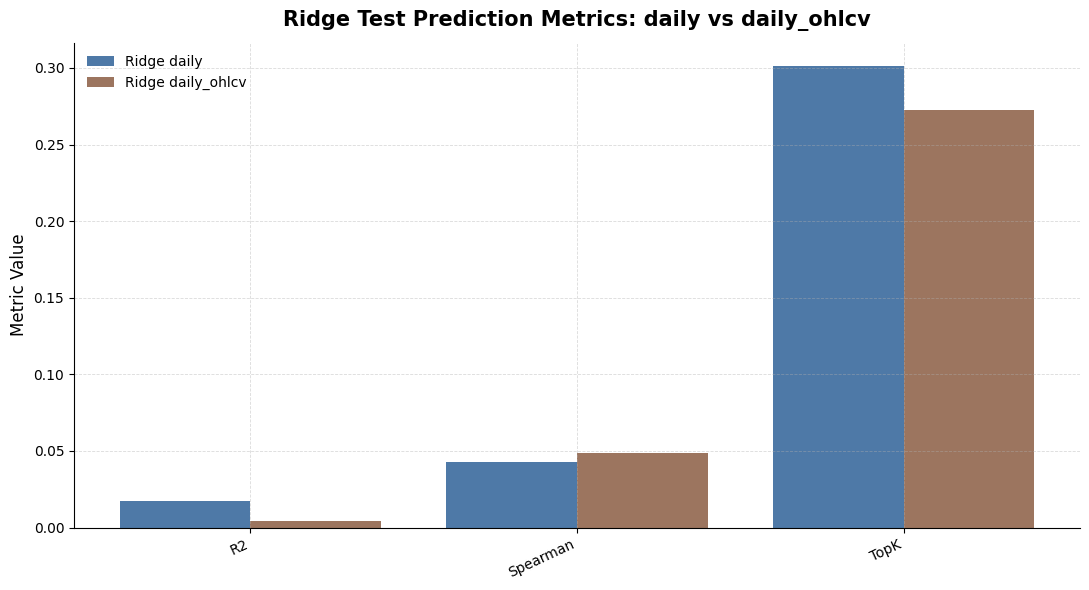

In [18]:
plot_grouped_metric_bars(
    metric_df=metric_plot_df,
    title="Ridge Test Prediction Metrics: daily vs daily_ohlcv",
    ylabel="Metric Value",
    color_map={
        "Ridge daily": get_model_color("ridge"),
        "Ridge daily_ohlcv": "#9C755F",
    },
    save_path=fig_path("ridge_test_prediction_metric_comparison.png"),
    show=True,
)

## 4. Equity curves

The cumulative-value paths of the two Ridge portfolios are compared below for both the training and test periods.

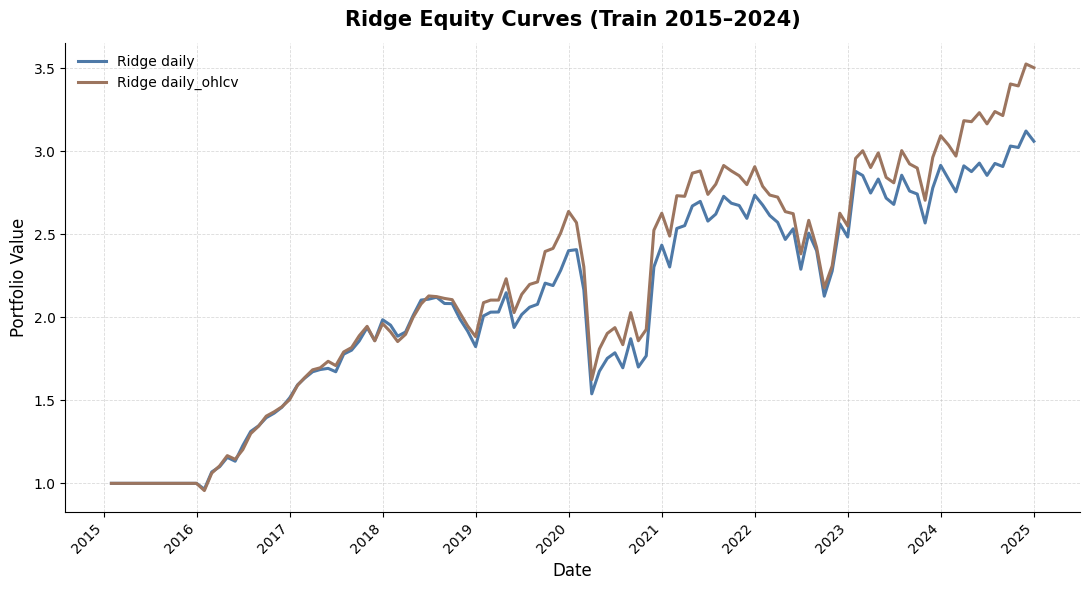

In [19]:
plot_multi_series(
    series_map={
        "Ridge daily": ridge_results["Ridge daily"]["equity_train"],
        "Ridge daily_ohlcv": ridge_results["Ridge daily_ohlcv"]["equity_train"],
    },
    title="Ridge Equity Curves (Train 2015–2024)",
    ylabel="Portfolio Value",
    color_map={
        "Ridge daily": get_model_color("ridge"),
        "Ridge daily_ohlcv": "#9C755F",
    },
    save_path=fig_path("ridge_equity_train_comparison.png"),
    show=True,
)

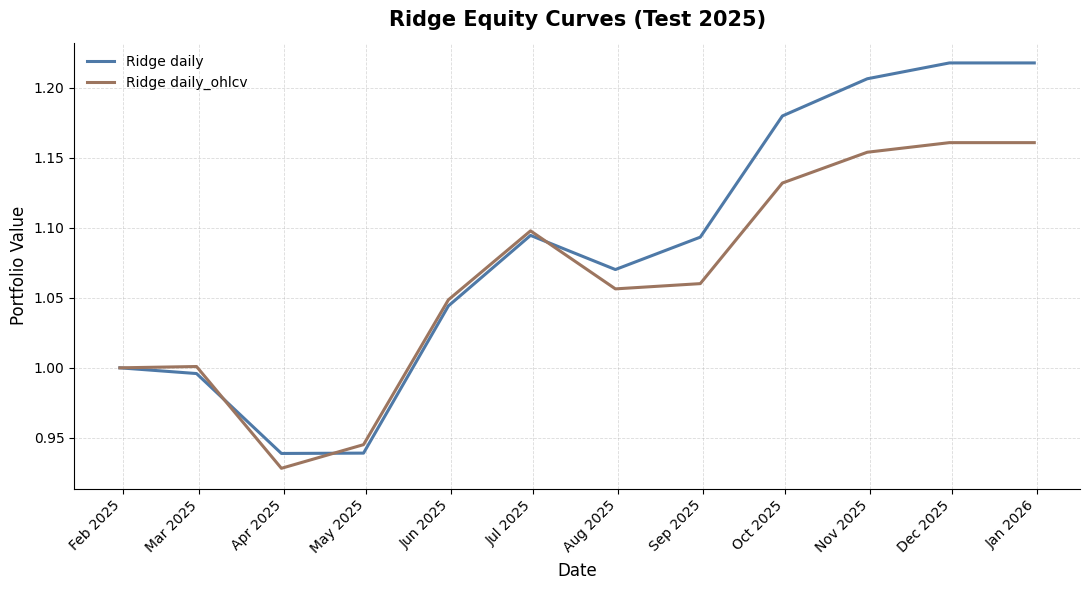

In [20]:
plot_multi_series(
    series_map={
        "Ridge daily": ridge_results["Ridge daily"]["equity_test"],
        "Ridge daily_ohlcv": ridge_results["Ridge daily_ohlcv"]["equity_test"],
    },
    title="Ridge Equity Curves (Test 2025)",
    ylabel="Portfolio Value",
    color_map={
        "Ridge daily": get_model_color("ridge"),
        "Ridge daily_ohlcv": "#9C755F",
    },
    save_path=fig_path("ridge_equity_test_comparison.png"),
    show=True,
)

## 5. Drawdowns

Drawdown plots complement the equity curves by showing the magnitude of declines from prior portfolio peaks.

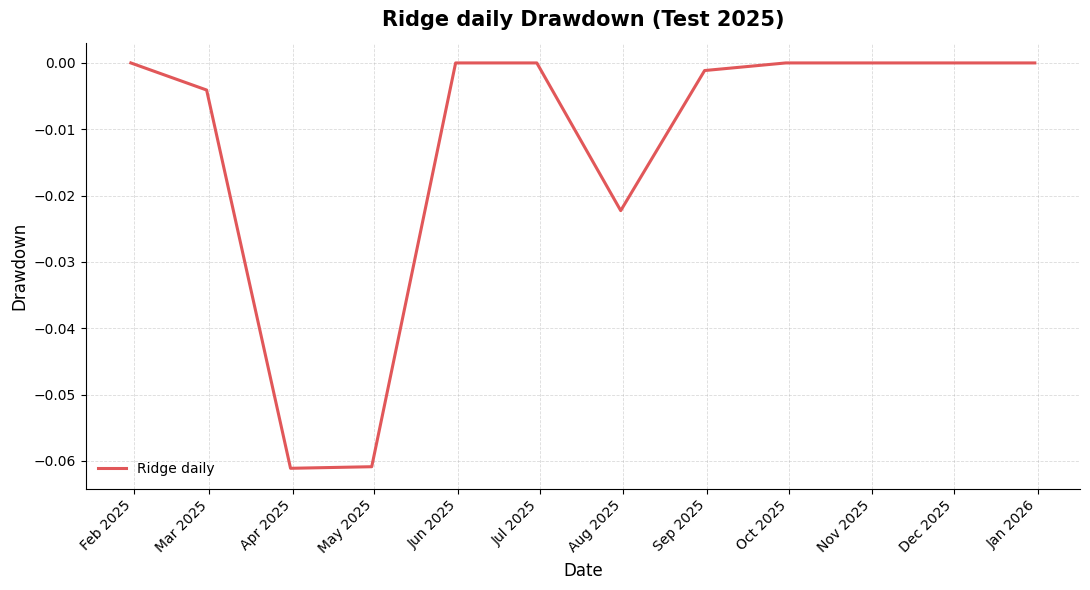

In [21]:
plot_drawdown(
    ridge_results["Ridge daily"]["equity_test"],
    title="Ridge daily Drawdown (Test 2025)",
    save_path=fig_path("ridge_daily_drawdown_test.png"),
    label="Ridge daily",
    color="#E15759",
    show=True,
)

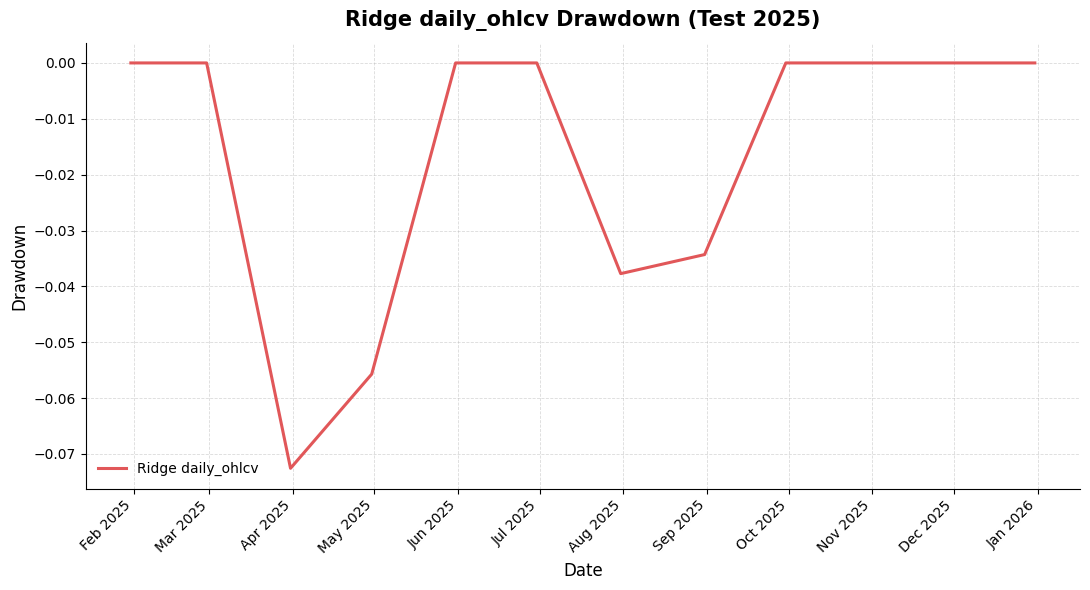

In [22]:
plot_drawdown(
    ridge_results["Ridge daily_ohlcv"]["equity_test"],
    title="Ridge daily_ohlcv Drawdown (Test 2025)",
    save_path=fig_path("ridge_daily_ohlcv_drawdown_test.png"),
    label="Ridge daily_ohlcv",
    color="#E15759",
    show=True,
)

In [23]:
test_strategy_df = ridge_strategy_comparison[ridge_strategy_comparison["split"] == "test_2025"].set_index("model")
test_strategy_df[["cumulative_return", "sharpe_ratio", "avg_turnover"]]

,cumulative_return,sharpe_ratio,avg_turnover
model,,,
Ridge daily,0.217607,1.341890,0.425837
Ridge daily_ohlcv,0.160716,0.999271,0.454545


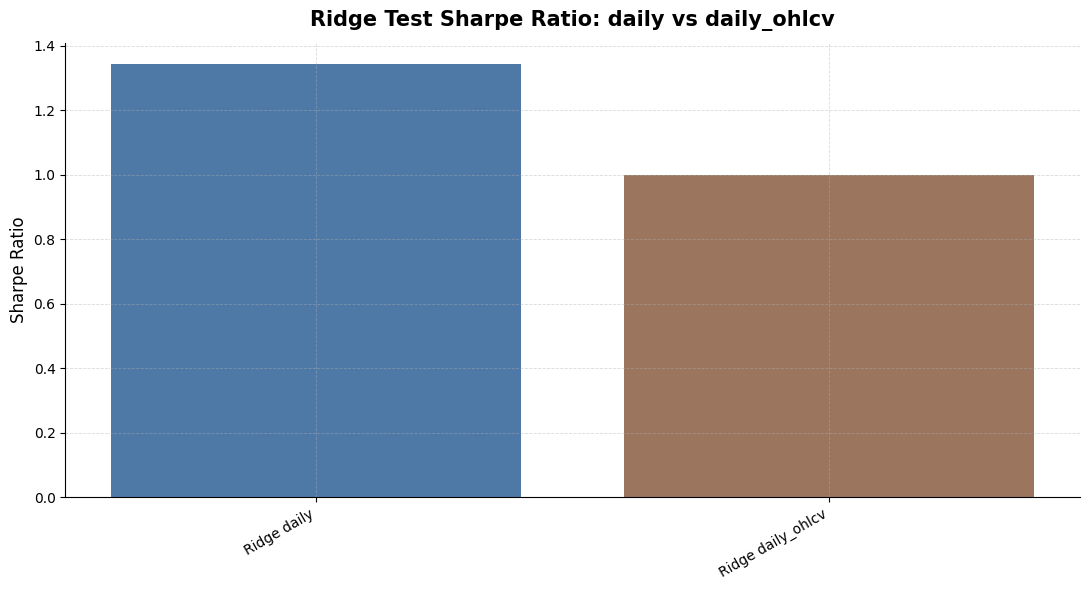

In [24]:
plot_metric_bar(
    test_strategy_df["sharpe_ratio"],
    title="Ridge Test Sharpe Ratio: daily vs daily_ohlcv",
    ylabel="Sharpe Ratio",
    color_map={
        "Ridge daily": get_model_color("ridge"),
        "Ridge daily_ohlcv": "#9C755F",
    },
    save_path=fig_path("ridge_test_sharpe_comparison.png"),
    show=True,
)

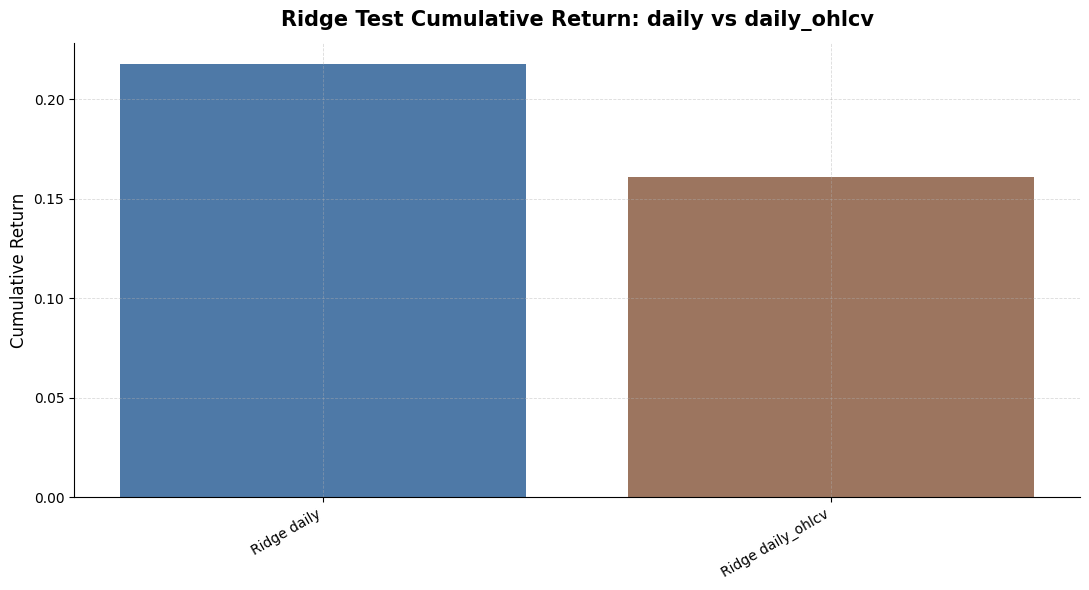

In [25]:
plot_metric_bar(
    test_strategy_df["cumulative_return"],
    title="Ridge Test Cumulative Return: daily vs daily_ohlcv",
    ylabel="Cumulative Return",
    color_map={
        "Ridge daily": get_model_color("ridge"),
        "Ridge daily_ohlcv": "#9C755F",
    },
    save_path=fig_path("ridge_test_cumulative_return_comparison.png"),
    show=True,
)

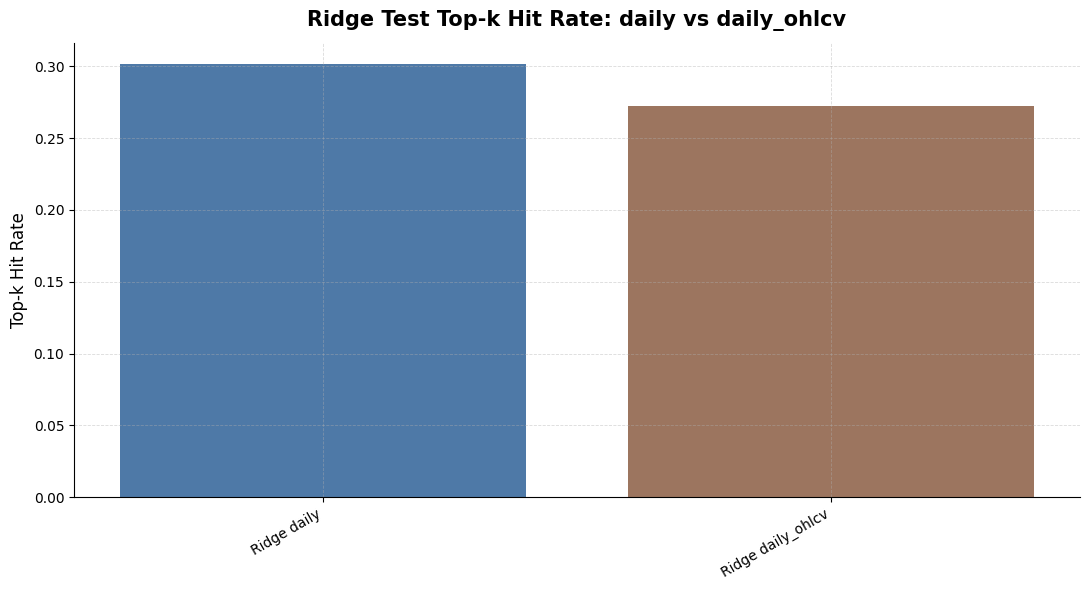

In [26]:
plot_metric_bar(
    test_pred_plot_df["TopKHitRate_mean"],
    title="Ridge Test Top-k Hit Rate: daily vs daily_ohlcv",
    ylabel="Top-k Hit Rate",
    color_map={
        "Ridge daily": get_model_color("ridge"),
        "Ridge daily_ohlcv": "#9C755F",
    },
    save_path=fig_path("ridge_test_topk_comparison.png"),
    show=True,
)

## 6. Cost sensitivity

Cost-adjusted metrics are used to assess how much the Ridge portfolios deteriorate when turnover-based transaction costs are applied.

In [27]:
ridge_cost_test_simple = ridge_cost_comparison[
    ridge_cost_comparison["split"] == "test_2025"
][["model", "cost_scenario", "cumulative_return", "sharpe_ratio"]]

ridge_cost_test_simple

,model,cost_scenario,cumulative_return,sharpe_ratio
3,Ridge daily,cost_0bps,0.217607,1.341890
4,Ridge daily,cost_10bps,0.212008,1.312170
5,Ridge daily,cost_20bps,0.206432,1.282412
9,Ridge daily_ohlcv,cost_0bps,0.160716,0.999271
10,Ridge daily_ohlcv,cost_10bps,0.155003,0.968834
11,Ridge daily_ohlcv,cost_20bps,0.149314,0.938351


In [28]:
save_table(ridge_cost_test_simple, "ridge_test_cost_comparison_simple.csv", index=False)

Saved table -> c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\reports\tables\notebook04\ridge_test_cost_comparison_simple.csv


## 7. Interpretation

The Ridge models provide a useful benchmark family because they introduce supervised learning in a simple and transparent form.

The comparison between `daily` and `daily_ohlcv` shows whether the richer OHLCV-based feature extension helps even a linear model. This matters because later nonlinear models also use these feature sources.

Although Ridge remains weaker than the strongest tree-based models later in the project, it still provides a meaningful baseline for both prediction and portfolio evaluation.

In [29]:
ridge_findings = pd.DataFrame(
    {
        "finding": [
            "Ridge establishes the first supervised-learning benchmark family",
            "The daily and daily_ohlcv variants can be compared directly",
            "OHLCV feature extension can be assessed even in a linear setting",
            "Out-of-sample predictive power remains modest for both Ridge variants",
            "Later nonlinear models should be judged relative to these linear baselines",
        ]
    }
)
ridge_findings

,finding
0,Ridge establishes the first supervised-learnin...
1,The daily and daily_ohlcv variants can be comp...
2,OHLCV feature extension can be assessed even i...
3,Out-of-sample predictive power remains modest ...
4,Later nonlinear models should be judged relati...


In [30]:
save_table(ridge_findings, "ridge_key_findings.csv", index=False)

Saved table -> c:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\reports\tables\notebook04\ridge_key_findings.csv


## 8. Final conclusion

The Ridge model family serves as the first supervised-learning benchmark in the project.

It provides:

- regularized linear prediction  
- transparent benchmark metrics  
- direct comparison between `daily` and `daily_ohlcv` feature sources  
- portfolio-level evaluation under transaction costs  

The next notebook studies the Random Forest model, which introduces nonlinear interactions and became the central model-development focus of the project.